# 01 · Unusual behaviour / anomaly detection (models.md §1)

One `IsolationForest` + `StandardScaler` per machine type on rolling-window telemetry features,
plus a sensor-glitch vs real-fault decision layer. Trained on the full 90-day synthetic run
(`data/output/telemetry.parquet`).

* Split by time: days 1–70 train, 71–80 validation, 81–90 test.
* Training rows exclude every failure drift window (from `maintenance_log` failures).
* `anomaly_label` / `anomaly_type` are **never** features. They and `data/output/truth/` are
  used only to evaluate (and to pick a threshold on validation).
* Evaluation covers **injected** anomaly types only. `pre_failure_*` belongs to predictive maintenance.

Feature code and decision logic live in `ml/inference/anomaly.py`, so notebook and backend
compute exactly the same thing.

In [1]:
import json, sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from ml.inference.anomaly import FEATURE_COLUMNS, INPUT_COLUMNS, build_features, classify

DATA = ROOT / "data" / "output"
ART = ROOT / "ml" / "artifacts" / "anomaly"
ART.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
START = pd.Timestamp("2026-06-01", tz="UTC")
IF_PARAMS = dict(n_estimators=200, contamination=0.03, max_samples="auto", max_features=1.0,
                 random_state=RANDOM_STATE)
INJECTED = ["overheating", "hydraulic_leak", "excessive_idle", "battery_fault", "sensor_glitch",
            "unsafe_operation"]
TAIL = pd.Timedelta(minutes=5)  # rolling features trail the event end by up to 5 min
pd.set_option("display.width", 160)

## 1 · Data

In [2]:
tel = (pd.read_parquet(DATA / "telemetry.parquet")
         .sort_values(["machine_id", "ts"], kind="stable").reset_index(drop=True))
machines = pd.read_csv(DATA / "machines.csv")
machine_map = machines.set_index("machine_id").machine_type.to_dict()
shifts = pd.read_csv(DATA / "shifts.csv", parse_dates=["start_time", "end_time"])
failures = pd.read_csv(DATA / "truth" / "failures.csv", parse_dates=["failure_ts"])
events = pd.read_csv(DATA / "truth" / "anomaly_events.csv", parse_dates=["start_ts", "end_ts"])

tel["machine_type"] = tel.machine_id.map(machine_map)
day = (tel.ts - START).dt.days + 1
tel["split"] = np.select([day <= 70, day <= 80], ["train", "val"], "test")
print(tel.shape, tel.groupby("split").size().to_dict())

(652228, 28) {'test': 74003, 'train': 506409, 'val': 71816}


### Failure drift windows
Drift windows are defined in **engine hours** (`drift_window_h`). Engine hours advance by the full
shift length (cut at a failure), not by telemetry rows, so rebuild them per shift and mark every
row within `W` engine hours before a failure. Check: the last 20 % of each window must coincide
with the `pre_failure_*` rows.

In [3]:
sh = shifts.sort_values(["machine_id", "start_time"]).copy()
shift_end = sh.shift_id.map(failures.set_index("shift_id").failure_ts).fillna(sh.end_time)
sh["dur_h"] = (pd.to_datetime(shift_end, utc=True) - sh.start_time).dt.total_seconds() / 3600
sh["eh0"] = sh.groupby("machine_id").dur_h.cumsum() - sh.dur_h

eh = tel[["shift_id", "ts"]].merge(sh[["shift_id", "eh0", "start_time"]], on="shift_id", how="left")
tel["engine_h"] = (eh.eh0 + (eh.ts - eh.start_time).dt.total_seconds() / 3600).to_numpy()
f = failures.merge(sh[["shift_id", "eh0", "start_time"]], on="shift_id")
f["eh_fail"] = f.eh0 + (f.failure_ts - f.start_time).dt.total_seconds() / 3600

in_drift = np.zeros(len(tel), bool)
last20 = np.zeros(len(tel), bool)
for r in f.itertuples():
    m = (tel.machine_id == r.machine_id).to_numpy() & (tel.engine_h <= r.eh_fail).to_numpy()
    in_drift |= m & (tel.engine_h >= r.eh_fail - r.drift_window_h).to_numpy()
    last20 |= m & (tel.engine_h >= r.eh_fail - 0.2 * r.drift_window_h).to_numpy()
tel["in_drift"] = in_drift

pre = tel.anomaly_type.fillna("").str.startswith("pre_failure").to_numpy()
print(f"drift rows {in_drift.sum():,}  | pre_failure rows {pre.sum():,}, "
      f"of which inside reconstructed last 20 %: {(pre & last20).sum():,}")
assert (pre & last20).sum() / pre.sum() > 0.999

drift rows 184,673  | pre_failure rows 37,143, of which inside reconstructed last 20 %: 37,142


## 2 · Features (models.md §1)
Per machine, per minute, trailing time-based windows: for each of the 9 signals the 5-min mean,
5-min std and 15-min slope; `idle_pct30`; `rpm_per_load`; `fuel_per_load`;
`coolant_minus_hyd_oil_c`. One model per machine type replaces the one-hot.

Before the windows are computed, single-minute sensor glitches are replaced by the previous
reading (see §4), so one spike does not contaminate the next 5 minutes of features.

In [4]:
feats, glitch = build_features(tel[INPUT_COLUMNS])       # explicit input columns only
assert (feats.machine_id.values == tel.machine_id.values).all() and (feats.ts.values == tel.ts.values).all()
assert not {"anomaly_label", "anomaly_type"} & set(FEATURE_COLUMNS)
print(len(FEATURE_COLUMNS), "features")
feats[FEATURE_COLUMNS].describe().T.round(2).head(12)

31 features


,count,mean,std,min,25%,50%,75%,max
engine_rpm_mean5,652228.0,1634.33,264.01,775.10,1510.26,1680.40,1825.32,2033.36
engine_rpm_std5,652228.0,85.11,107.12,0.00,18.38,32.51,94.62,557.41
engine_rpm_slope15,652228.0,1.49,30.01,-113.34,-10.88,0.44,12.64,147.86
engine_load_pct_mean5,652228.0,52.15,19.89,0.72,40.55,53.63,67.15,89.96
engine_load_pct_std5,652228.0,6.67,7.04,0.00,2.02,3.40,8.13,39.79
engine_load_pct_slope15,652228.0,0.09,2.11,-7.66,-0.95,0.04,1.09,10.50
coolant_temp_c_mean5,652228.0,87.38,4.22,76.68,83.93,87.19,90.55,114.69
coolant_temp_c_std5,652228.0,0.41,0.31,0.00,0.21,0.34,0.54,9.81
coolant_temp_c_slope15,652228.0,0.01,0.24,-14.24,-0.13,0.01,0.15,2.26
oil_pressure_kpa_mean5,652228.0,316.19,61.48,36.62,281.14,318.92,363.96,433.94


## 3 · Train: one IsolationForest + StandardScaler per machine type
Fitted on training days only, excluding drift windows. `anomaly_score` = `-score_samples()`
min–max scaled to 0–1 using the training range; the model flags a minute when the raw score
exceeds the threshold implied by `contamination=0.03`.

In [5]:
train_mask = (tel.split == "train").to_numpy() & ~tel.in_drift.to_numpy()
X_all = feats[FEATURE_COLUMNS].to_numpy(float)
raw = np.zeros(len(tel)); Z = np.zeros_like(X_all)
models, scalers, score_scale, n_train = {}, {}, {}, {}
for mt in sorted(tel.machine_type.unique()):
    rows = (tel.machine_type == mt).to_numpy()
    fit_rows = rows & train_mask
    scaler = StandardScaler().fit(X_all[fit_rows])
    model = IsolationForest(**IF_PARAMS, n_jobs=-1).fit(scaler.transform(X_all[fit_rows]))
    Z[rows] = scaler.transform(X_all[rows])
    raw[rows] = -model.score_samples(Z[rows])
    tr = raw[fit_rows]
    score_scale[mt] = {"min": float(tr.min()), "max": float(tr.max()), "threshold": float(-model.offset_)}
    models[mt], scalers[mt], n_train[mt] = model, scaler, int(fit_rows.sum())
print(n_train)
pd.DataFrame(score_scale).T

{'articulated_truck': 61048, 'dozer': 55112, 'excavator': 115600, 'wheel_loader': 103542}


,min,max,threshold
articulated_truck,0.367459,0.672920,0.546524
dozer,0.365774,0.645039,0.539696
excavator,0.365808,0.645831,0.546925
wheel_loader,0.362086,0.664074,0.547964


## 4 · Sensor glitch vs real fault
* **Sensor glitch** (`kind='sensor_glitch'`, info): exactly one signal reads outside its sensor
  validity range (e.g. coolant 0 or 150 °C, battery 0 V, oil pressure 0 with the engine running)
  and that signal was plausible the minute before. Causal — needs only t−1 and t.
* **Real fault** (`kind='machine_fault'`): the model flag has persisted ≥ 3 minutes, **or** at least
  two distinct signals have a feature with |z| ≥ 3.
* Anything else is `normal` (a single-minute, single-signal model flag is not raised yet).

In [6]:
def model_kind(threshold_by_type):
    flagged = raw > tel.machine_type.map(threshold_by_type).to_numpy()
    return classify(tel.machine_id, tel.ts, flagged, Z, glitch), flagged

spec_thr = {mt: s["threshold"] for mt, s in score_scale.items()}
kind, flagged = model_kind(spec_thr)
at = tel.anomaly_type.fillna("none").to_numpy()
pd.crosstab(at[tel.split == "test"], kind[tel.split == "test"])

col_0,machine_fault,normal,sensor_glitch
row_0,,,
battery_fault,36,578,0
excessive_idle,14,898,0
hydraulic_leak,27,271,0
none,1148,68590,0
overheating,129,289,0
pre_failure_electrical,25,927,0
pre_failure_undercarriage,7,940,0
sensor_glitch,0,0,19
unsafe_operation,20,85,0


## 5 · Rules-only baseline (models.md §R)
The alert rule engine's thresholds, applied to the same telemetry. `SEATBELT` is a behaviour rule,
not a machine anomaly, and `OVERSPEED` has no type limits defined yet; both are left out.

In [7]:
def run_len(cond, key):
    c = pd.Series(np.asarray(cond, bool))
    grp = (~c | key.ne(key.shift()).to_numpy()).cumsum()
    return c.astype(int).groupby(grp.to_numpy()).cumsum().to_numpy()

key = tel.shift_id
hp_prev3 = tel.groupby("shift_id").hydraulic_pressure_bar.transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
rules = pd.DataFrame({
    "COOLANT_HIGH": run_len(tel.coolant_temp_c > 100, key) >= 2,
    "COOLANT_CRITICAL": tel.coolant_temp_c > 105,
    "HYD_OIL_HIGH": tel.hydraulic_oil_temp_c > 90,
    "OIL_PRESSURE_LOW": (tel.oil_pressure_kpa < 100) & (tel.engine_rpm > 1200),
    "BATTERY_LOW": run_len(tel.battery_voltage < 24, key) >= 5,
    "HYD_PRESSURE_DROP": (tel.hydraulic_pressure_bar < 0.65 * hp_prev3) & (tel.engine_load_pct > 40) & (hp_prev3 > 100),
    "TIP_RISK": (tel.pitch_deg.abs() > 15) | (tel.roll_deg.abs() > 15),
    "EXCESS_IDLE": run_len(tel.is_idle.to_numpy(bool), key) > 10,
    "FAULT_CODE": tel.fault_code.notna(),
}).astype(bool)
rule_alert = rules.any(axis=1).to_numpy()
print("share of normal test minutes where each rule fires:")
rules[(tel.split == "test").to_numpy() & (at == "none")].mean().round(4)

share of normal test minutes where each rule fires:


COOLANT_HIGH         0.0000
COOLANT_CRITICAL     0.0000
HYD_OIL_HIGH         0.0000
OIL_PRESSURE_LOW     0.0000
BATTERY_LOW          0.0000
HYD_PRESSURE_DROP    0.0238
TIP_RISK             0.0000
EXCESS_IDLE          0.0077
FAULT_CODE           0.0000
dtype: float64

## 6 · Evaluation
Three detectors: **rules only**, **model only** and **rules + model** (what ships: a rule or a
confirmed model fault alerts; a minute the model marks `sensor_glitch` is downgraded to info,
which suppresses the rules' false critical alert).

Metrics, per injected `anomaly_type`, on the chosen split:
* **Event recall** — share of events with a correct alert between start and end + 5 min
  (`sensor_glitch` must be classified as a glitch; every other type as a fault).
* **Median detection delay** — minutes from event start to the first correct alert.
* **Minute precision / recall / F1** — one type vs normal minutes: the population is the normal
  minutes plus that type's minutes (other types, `pre_failure_*` rows and the 5-min tails are left out).
* Overall: false alert episodes (runs of alerting minutes that touch no injected event) per
  100 machine-hours of normal operation.

In [8]:
ev_all = events[events.anomaly_type.isin(INJECTED)].copy()
tel_idx = {m: (g.index.to_numpy(), g.ts.dt.tz_convert(None).to_numpy()) for m, g in tel.groupby("machine_id")}

# rows inside an injected event (+ tail), per type
event_rows = np.zeros(len(tel), bool); tail_rows = np.zeros(len(tel), bool)
for e in ev_all.itertuples():
    idx, ts = tel_idx[e.machine_id]
    s, en, t = [np.datetime64(x.tz_convert(None)) for x in (e.start_ts, e.end_ts, e.end_ts + TAIL)]
    event_rows[idx[(ts >= s) & (ts < en)]] = True
    tail_rows[idx[(ts >= en) & (ts < t)]] = True

def detectors(kind):
    fault = kind == "machine_fault"; gl = kind == "sensor_glitch"
    return {
        "rules": {"fault": rule_alert, "glitch": np.zeros(len(tel), bool)},
        "model": {"fault": fault, "glitch": gl},
        "rules+model": {"fault": (rule_alert & ~gl) | fault, "glitch": gl},
    }

def evaluate(kind, split):
    in_split = (tel.split == split).to_numpy()
    ev = ev_all[ev_all.start_ts.map(lambda t: (t - START).days + 1).between(*{"val": (71, 80), "test": (81, 90)}[split])]
    normal = in_split & (at == "none") & ~tail_rows
    out, overall = {}, {}
    for name, d in detectors(kind).items():
        per = {}
        rec_all, delay_all = [], []
        for typ in INJECTED:
            alert = d["glitch"] if typ == "sensor_glitch" else d["fault"]
            hits, delays = [], []
            for e in ev[ev.anomaly_type == typ].itertuples():
                idx, ts = tel_idx[e.machine_id]
                w = idx[(ts >= np.datetime64(e.start_ts.tz_convert(None))) & (ts < np.datetime64((e.end_ts + TAIL).tz_convert(None)))]
                h = w[alert[w]]
                hits.append(len(h) > 0)
                if len(h):
                    delays.append((tel.ts.iat[h[0]] - e.start_ts).total_seconds() / 60)
            pos = in_split & (at == typ)
            tp, fn, fp = (alert & pos).sum(), (~alert & pos).sum(), (alert & normal).sum()
            p = tp / (tp + fp) if tp + fp else 0.0; r = tp / (tp + fn) if tp + fn else 0.0
            per[typ] = {"events": len(hits), "event_recall": round(float(np.mean(hits)), 3),
                        "median_delay_min": round(float(np.median(delays)), 1) if delays else None,
                        "minute_precision": round(float(p), 3), "minute_recall": round(float(r), 3),
                        "minute_f1": round(float(2 * p * r / (p + r)) if p + r else 0.0, 3)}
            rec_all += hits; delay_all += delays
        any_alert = d["fault"] | d["glitch"]
        # false alert episodes: runs of alert minutes (same shift) that touch no event row / tail
        a = pd.Series(any_alert & in_split)
        start = a & ~(a.shift(fill_value=False) & tel.shift_id.eq(tel.shift_id.shift()))
        run = start.cumsum().where(a)
        touches = pd.Series(event_rows | tail_rows | (at != "none")).groupby(run).any()
        n_false = int((~touches).sum())
        hours = normal.sum() / 60
        overall = {"event_recall": round(float(np.mean(rec_all)), 3),
                   "median_delay_min": round(float(np.median(delay_all)), 1),
                   "false_alerts_per_100_machine_h": round(100 * n_false / hours, 2),
                   "normal_minutes_alerting_pct": round(100 * float(any_alert[normal].mean()), 2)}
        out[name] = {"per_type": per, "overall": overall}
    return out

def table(res, cols=("event_recall", "median_delay_min", "minute_precision", "minute_recall", "minute_f1")):
    return pd.concat({k: pd.DataFrame(v["per_type"]).T[list(cols)] for k, v in res.items()}, axis=1)

val_spec = evaluate(kind, "val")
print(pd.DataFrame({k: v["overall"] for k, v in val_spec.items()}))
table(val_spec)

                                 rules   model  rules+model
event_recall                     0.725   0.525         1.00
median_delay_min                 2.000   0.000         1.00
false_alerts_per_100_machine_h  90.330  50.350       138.25
normal_minutes_alerting_pct      3.090   1.600         4.66


rules                                                                  model                                                  \
                 event_recall median_delay_min minute_precision minute_recall minute_f1 event_recall median_delay_min minute_precision minute_recall   
overheating             1.000             11.0            0.027         0.374     0.051        1.000             21.0            0.027         0.194   
hydraulic_leak          0.923              1.5            0.070         0.602     0.126        0.385             10.0            0.010         0.042   
excessive_idle          1.000             10.0            0.181         0.794     0.295        0.357              2.0            0.011         0.021   
battery_fault           1.000              2.0            0.202         0.919     0.331        0.500              8.0            0.017         0.032   
sensor_glitch           0.000              NaN            0.000         0.000     0.000        1.000              0.0            1.000         1.000   
unsafe_operation        1.000              1.0            0.051         0.617     0.094        0.059              0.0            0.001         0.006   

                            rules+model                                                            
                 minute_f1 event_recall median_delay_min minute_precision minute_recall minute_f1  
overheating          0.048          1.0             11.0            0.025         0.516     0.048  
hydraulic_leak       0.016          1.0              2.0            0.051         0.641     0.094  
excessive_idle       0.015          1.0              8.0            0.130         0.813     0.225  
battery_fault        0.022          1.0              2.0            0.143         0.919     0.248  
sensor_glitch        1.000          1.0              0.0            1.000         1.000     1.000  
unsafe_operation     0.002          1.0              1.0            0.035         0.622     0.066

## 7 · One tuning round (validation only)
The spec threshold (contamination 0.03) misses the targets on validation. The one tuning round
sweeps the model's decision threshold (quantile of each type's training scores) and the
persistence rule is unchanged. Feature list and model parameters stay as specified.

In [9]:
sweep = []
for q in [0.97, 0.95, 0.93, 0.90, 0.85]:
    thr = {mt: float(np.quantile(raw[(tel.machine_type == mt).to_numpy() & train_mask], q)) for mt in score_scale}
    k, _ = model_kind(thr)
    o = evaluate(k, "val")["model"]
    sweep.append({"train_quantile": q, **o["overall"],
                  **{f"recall_{t}": o["per_type"][t]["event_recall"] for t in INJECTED}})
sweep = pd.DataFrame(sweep)
sweep

,train_quantile,event_recall,median_delay_min,false_alerts_per_100_machine_h,normal_minutes_alerting_pct,recall_overheating,recall_hydraulic_leak,recall_excessive_idle,recall_battery_fault,recall_sensor_glitch,recall_unsafe_operation
0,0.97,0.525,0.0,50.35,1.60,1.0,0.385,0.357,0.5,1.0,0.059
1,0.95,0.550,0.0,72.50,2.84,1.0,0.462,0.429,0.5,1.0,0.059
2,0.93,0.588,0.0,90.33,4.09,1.0,0.538,0.429,0.6,1.0,0.118
3,0.90,0.662,0.0,111.32,5.97,1.0,0.538,0.857,0.6,1.0,0.118
4,0.85,0.738,1.0,136.00,9.53,1.0,0.538,1.000,0.6,1.0,0.353


**Decision:** no threshold reaches recall ≥ 0.8 on validation. Going from the spec threshold (0.97)
to the 0.85 quantile nearly triples false alerts (≈ 50 → 136 per 100 machine-hours) and lifts
recall only to 0.74, mostly through `excessive_idle`; `hydraulic_leak` stays at 0.54 and
`battery_fault` at 0.6. The weakness is in how the model sees the data, not the cut-off, so
**we keep the spec threshold** (contamination 0.03). Why each type misses is in
`ml/artifacts/anomaly/README.md`.

## 8 · Test results (days 81–90)

In [10]:
test_res = evaluate(kind, "test")
print(pd.DataFrame({k: v["overall"] for k, v in test_res.items()}))
table(test_res)

                                rules   model  rules+model
event_recall                     0.77   0.621         1.00
median_delay_min                 6.00   3.000         2.00
false_alerts_per_100_machine_h  90.73  50.040       138.26
normal_minutes_alerting_pct      3.12   1.610         4.71


rules                                                                  model                                                  \
                 event_recall median_delay_min minute_precision minute_recall minute_f1 event_recall median_delay_min minute_precision minute_recall   
overheating             1.000              9.5            0.066         0.366     0.112        1.000             17.5            0.104         0.309   
hydraulic_leak          0.929              2.0            0.080         0.634     0.143        0.500             12.0            0.024         0.091   
excessive_idle          1.000             10.0            0.251         0.795     0.381        0.238             49.0            0.012         0.015   
battery_fault           1.000              4.0            0.208         0.923     0.339        0.750              9.0            0.031         0.059   
sensor_glitch           0.000              NaN            0.000         0.000     0.000        1.000              0.0            1.000         1.000   
unsafe_operation        1.000              1.0            0.032         0.676     0.061        0.273              0.0            0.018         0.190   

                            rules+model                                                            
                 minute_f1 event_recall median_delay_min minute_precision minute_recall minute_f1  
overheating          0.155          1.0              9.5            0.070         0.589     0.125  
hydraulic_leak       0.037          1.0              2.0            0.055         0.641     0.102  
excessive_idle       0.014          1.0             10.0            0.184         0.808     0.300  
battery_fault        0.041          1.0              2.0            0.151         0.945     0.260  
sensor_glitch        1.000          1.0              0.0            1.000         1.000     1.000  
unsafe_operation     0.032          1.0              1.0            0.024         0.752     0.046

In [11]:
TARGET_RECALL, TARGET_DELAY = 0.8, 5.0
m = test_res["model"]["overall"]
targets = {"recall_ge_0.8": m["event_recall"] >= TARGET_RECALL,
           "median_delay_le_5_min": m["median_delay_min"] <= TARGET_DELAY}
missing = {t: v for t, v in test_res["model"]["per_type"].items()
           if v["event_recall"] < TARGET_RECALL or (v["median_delay_min"] or 99) > TARGET_DELAY}
print("targets met (model):", targets)
pd.DataFrame(missing).T[["events", "event_recall", "median_delay_min"]]

targets met (model): {'recall_ge_0.8': False, 'median_delay_le_5_min': True}


,events,event_recall,median_delay_min
overheating,14.0,1.000,17.5
hydraulic_leak,14.0,0.500,12.0
excessive_idle,21.0,0.238,49.0
battery_fault,8.0,0.750,9.0
sensor_glitch,19.0,1.000,0.0
unsafe_operation,11.0,0.273,0.0


## 9 · Result chart

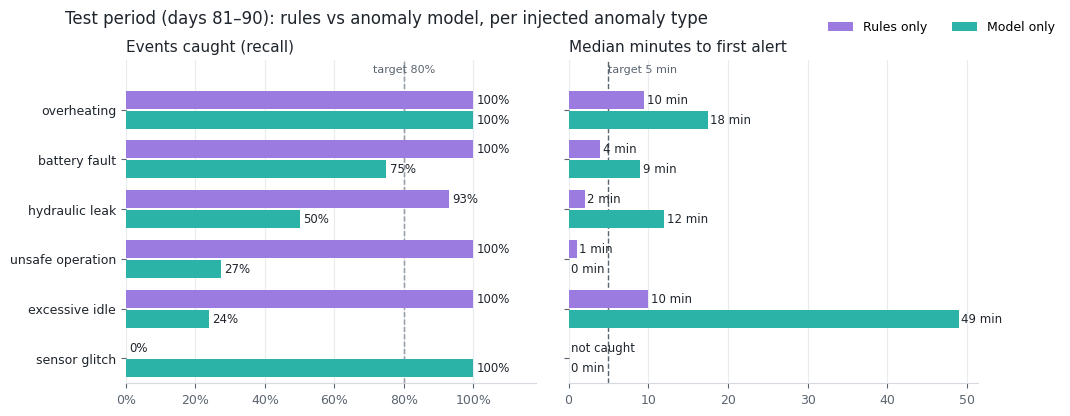

In [12]:
# design.md categorical tokens: teal and violet (validated: CVD dE 12.0, normal-vision dE 21.8)
TEAL, VIOLET, INK, MUTED, GRID = "#2BB3A8", "#9B7BE0", "#1F252C", "#5B6570", "#D5DAE0"
order = ["overheating", "battery_fault", "hydraulic_leak", "unsafe_operation", "excessive_idle", "sensor_glitch"]
series = [("Rules only", "rules", VIOLET), ("Model only", "model", TEAL)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, gridspec_kw={"wspace": 0.08})
y = np.arange(len(order)); h = 0.36
for ax, metric, title, fmt in [(axes[0], "event_recall", "Events caught (recall)", "{:.0%}"),
                               (axes[1], "median_delay_min", "Median minutes to first alert", "{:.0f} min")]:
    for i, (label, keyname, color) in enumerate(series):
        vals = [test_res[keyname]["per_type"][t][metric] for t in order]
        pos = y + (i - 0.5) * (h + 0.04)
        ax.barh(pos, [v or 0 for v in vals], height=h, color=color, label=label)
        for p_, v in zip(pos, vals):
            ax.text((v or 0) + (0.01 if metric == "event_recall" else 0.3), p_,
                    "not caught" if v is None else fmt.format(v), va="center", fontsize=8.5, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.grid(axis="x", color=GRID, alpha=0.5); ax.set_axisbelow(True)
    for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9); ax.spines["bottom"].set_color(GRID)
axes[0].axvline(0.8, color=MUTED, lw=1, ls="--", zorder=0); axes[0].text(0.8, -0.75, "target 80%", fontsize=8, color=MUTED, ha="center")
axes[1].axvline(5, color=MUTED, lw=1, ls="--", zorder=0); axes[1].text(5, -0.75, "target 5 min", fontsize=8, color=MUTED, ha="left")
axes[0].set_xlim(0, 1.18); axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_yticks(y, [t.replace("_", " ") for t in order], color=INK)
axes[0].set_ylim(len(order) - 0.5, -1.0)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.98, 1.0))
fig.suptitle("Test period (days 81–90): rules vs anomaly model, per injected anomaly type", fontsize=12, color=INK, x=0.07, ha="left", y=1.0)
fig.savefig(ART / "recall_delay.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 10 · Save artifacts

In [13]:
for mt in models:
    joblib.dump(models[mt], ART / f"iforest_{mt}.joblib")
    joblib.dump(scalers[mt], ART / f"scaler_{mt}.joblib")
(ART / "feature_list.json").write_text(json.dumps(FEATURE_COLUMNS, indent=2))
config = {"version": "v1", "machine_types": sorted(models), "machine_map": machine_map,
          "score_scale": score_scale, "isolation_forest": IF_PARAMS,
          "persist_min": 3, "multi_signal_z": 3.0}
(ART / "config.json").write_text(json.dumps(config, indent=2))
metrics = {
    "model_name": "anomaly", "version": "v1", "sklearn_version": sklearn.__version__,
    "split": {"train_days": [1, 70], "val_days": [71, 80], "test_days": [81, 90]},
    "train_rows": n_train, "train_excludes": "failure drift windows (engine hours, full W)",
    "evaluated_types": INJECTED, "event_tail_min": 5,
    "targets": {"recall": TARGET_RECALL, "median_delay_min": TARGET_DELAY, "met_by_model": targets},
    "test": test_res, "validation": val_spec,
    "tuning_round_validation": sweep.to_dict(orient="records"),
    "decision": "kept the spec threshold (contamination=0.03); lower thresholds raise false alerts faster than recall",
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2, default=lambda o: bool(o) if isinstance(o, np.bool_) else float(o)))
sorted(p.name for p in ART.iterdir())

['config.json',
 'feature_list.json',
 'iforest_articulated_truck.joblib',
 'iforest_dozer.joblib',
 'iforest_excavator.joblib',
 'iforest_wheel_loader.joblib',
 'metrics.json',
 'recall_delay.png',
 'scaler_articulated_truck.joblib',
 'scaler_dozer.joblib',
 'scaler_excavator.joblib',
 'scaler_wheel_loader.joblib']

## 11 · Parity check: live scoring = batch scoring
`score_anomaly` on a trailing 60-minute window must give the same score as the batch pipeline
for the same minute.

In [14]:
import importlib, ml.inference.anomaly as A
importlib.reload(A)
rng = np.random.default_rng(RANDOM_STATE)
sample = rng.choice(np.flatnonzero((tel.split == "test").to_numpy()), 25, replace=False)
bad = 0
for i in sample:
    row = tel.iloc[i]
    win = tel[(tel.machine_id == row.machine_id) & (tel.ts > row.ts - pd.Timedelta(minutes=60)) & (tel.ts <= row.ts)]
    live = A.score_anomaly(win[INPUT_COLUMNS])
    mt = row.machine_type; c = score_scale[mt]
    batch = float(np.clip((raw[i] - c["min"]) / (c["max"] - c["min"]), 0, 1))
    bad += abs(live["anomaly_score"] - round(batch, 3)) > 1e-3
print("mismatches:", bad, "of", len(sample)); assert bad == 0
live

mismatches: 0 of 25


{'machine_id': 'M07',
 'ts': '2026-08-20T14:25:00Z',
 'anomaly_score': 0.069,
 'is_anomaly': False,
 'kind': 'normal',
 'top_signals': [{'feature': 'coolant_temp_c_mean5', 'z': 1.44},
  {'feature': 'oil_pressure_kpa_mean5', 'z': 0.95},
  {'feature': 'idle_pct30', 'z': -0.84}]}